# Регрессионный анализ

Кольчурин Андрей Николавеич

студент физико-математического института,

направления радиофизика,

группы ФМ/О РФЗ-1-2022 НБ

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import f_regression, SelectKBest
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Загрузка и первичный анализ данных

In [2]:
# Загрузка данных
df = pd.read_csv('cirrhosis1.csv')

In [3]:
#Размер
df.shape

(312, 20)

In [4]:
df.head()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,2.0,0.0,21464,0.0,1.0,1.0,1.0,2.0,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,0.0,0.0,20617,0.0,0.0,1.0,1.0,0.0,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,2.0,0.0,25594,1.0,0.0,0.0,0.0,1.0,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,2.0,0.0,19994,0.0,0.0,1.0,1.0,1.0,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,1.0,1.0,13918,0.0,0.0,1.0,1.0,0.0,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


In [5]:
#Информация о датасете
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 312 entries, 0 to 311
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             312 non-null    int64  
 1   N_Days         312 non-null    int64  
 2   Status         312 non-null    float64
 3   Drug           312 non-null    float64
 4   Age            312 non-null    int64  
 5   Sex            312 non-null    float64
 6   Ascites        312 non-null    float64
 7   Hepatomegaly   312 non-null    float64
 8   Spiders        312 non-null    float64
 9   Edema          312 non-null    float64
 10  Bilirubin      312 non-null    float64
 11  Cholesterol    312 non-null    float64
 12  Albumin        312 non-null    float64
 13  Copper         312 non-null    float64
 14  Alk_Phos       312 non-null    float64
 15  SGOT           312 non-null    float64
 16  Tryglicerides  312 non-null    float64
 17  Platelets      312 non-null    float64
 18  Prothrombi

In [6]:
#Описательная статистика
df.describe()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
count,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000
mean,156.500000,2006.362179,0.862179,0.493590,18269.442308,0.115385,0.076923,0.512821,0.288462,0.221154,3.256090,364.125000,3.520000,97.490385,1982.655769,122.556346,123.096154,261.871795,10.725641,3.032051
std,90.210864,1123.280843,0.960764,0.500762,3864.805407,0.319999,0.266897,0.500639,0.453775,0.549014,4.530315,221.923027,0.419892,85.360932,2140.388824,56.699525,62.122820,94.993533,1.004323,0.877880
min,1.000000,41.000000,0.000000,0.000000,9598.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.300000,120.000000,1.960000,4.000000,289.000000,26.350000,33.000000,62.000000,9.000000,1.000000
25%,78.750000,1191.000000,0.000000,0.000000,15427.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.800000,255.750000,3.310000,41.750000,871.500000,80.600000,87.000000,200.000000,10.000000,2.000000
50%,156.500000,1839.500000,0.000000,0.000000,18187.500000,0.000000,0.000000,1.000000,0.000000,0.000000,1.350000,309.500000,3.550000,73.000000,1259.000000,114.700000,108.000000,257.000000,10.600000,3.000000
75%,234.250000,2697.250000,2.000000,1.000000,20715.000000,0.000000,0.000000,1.000000,1.000000,0.000000,3.425000,392.250000,3.800000,123.000000,1980.000000,151.900000,145.250000,322.000000,11.100000,4.000000
max,312.000000,4556.000000,2.000000,1.000000,28650.000000,1.000000,1.000000,1.000000,1.000000,2.000000,28.000000,1775.000000,4.640000,588.000000,13862.400000,457.250000,598.000000,563.000000,17.100000,4.000000


# Визуализация распределения целевой переменной и признаков

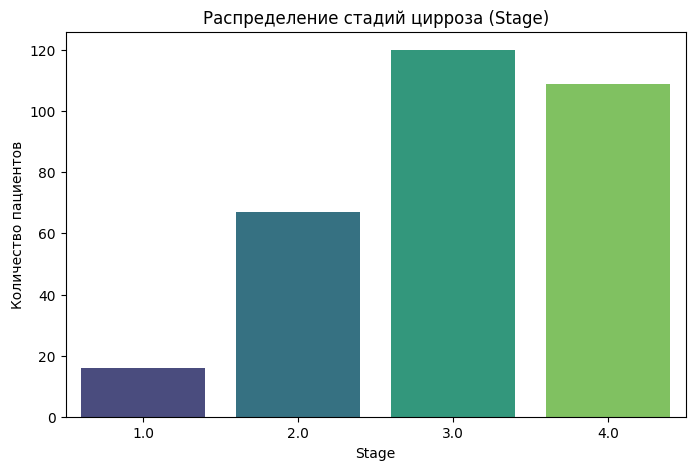

In [7]:
# Анализ распределения целевой переменной
plt.figure(figsize=(8, 5))
sns.countplot(x='Stage', data=df, palette='viridis')
plt.title('Распределение стадий цирроза (Stage)')
plt.xlabel('Stage')
plt.ylabel('Количество пациентов')
plt.show()

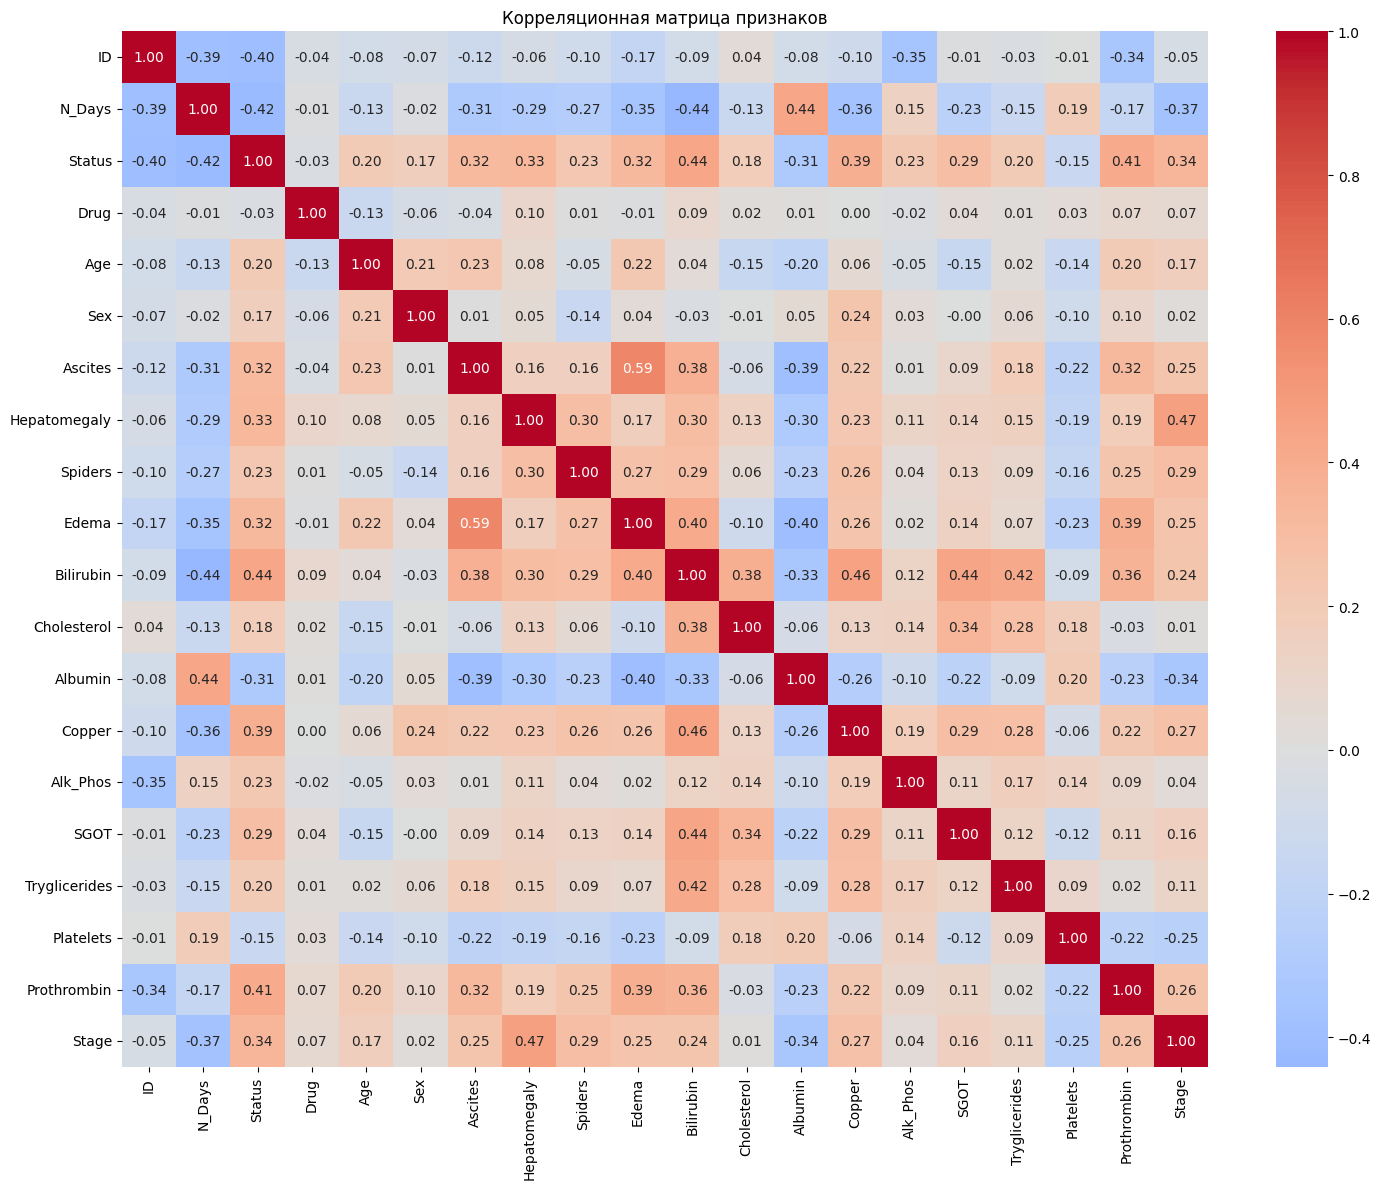

In [8]:
# Корреляционная матрица
plt.figure(figsize=(15, 12))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляционная матрица признаков')
plt.tight_layout()
plt.show()

In [9]:
# Корреляция с целевой переменной
stage_corr = df.corr()['Stage'].sort_values(ascending=False)
print("\nКорреляция признаков с целевой переменной Stage:")
print(stage_corr)


Корреляция признаков с целевой переменной Stage:
Stage            1.000000
Hepatomegaly     0.467293
Status           0.344549
Spiders          0.291512
Copper           0.268269
Prothrombin      0.260917
Edema            0.252104
Ascites          0.250187
Bilirubin        0.241367
Age              0.168182
SGOT             0.164945
Tryglicerides    0.113971
Drug             0.066298
Alk_Phos         0.041273
Sex              0.021131
Cholesterol      0.009271
ID              -0.050346
Platelets       -0.246951
Albumin         -0.336970
N_Days          -0.371641
Name: Stage, dtype: float64


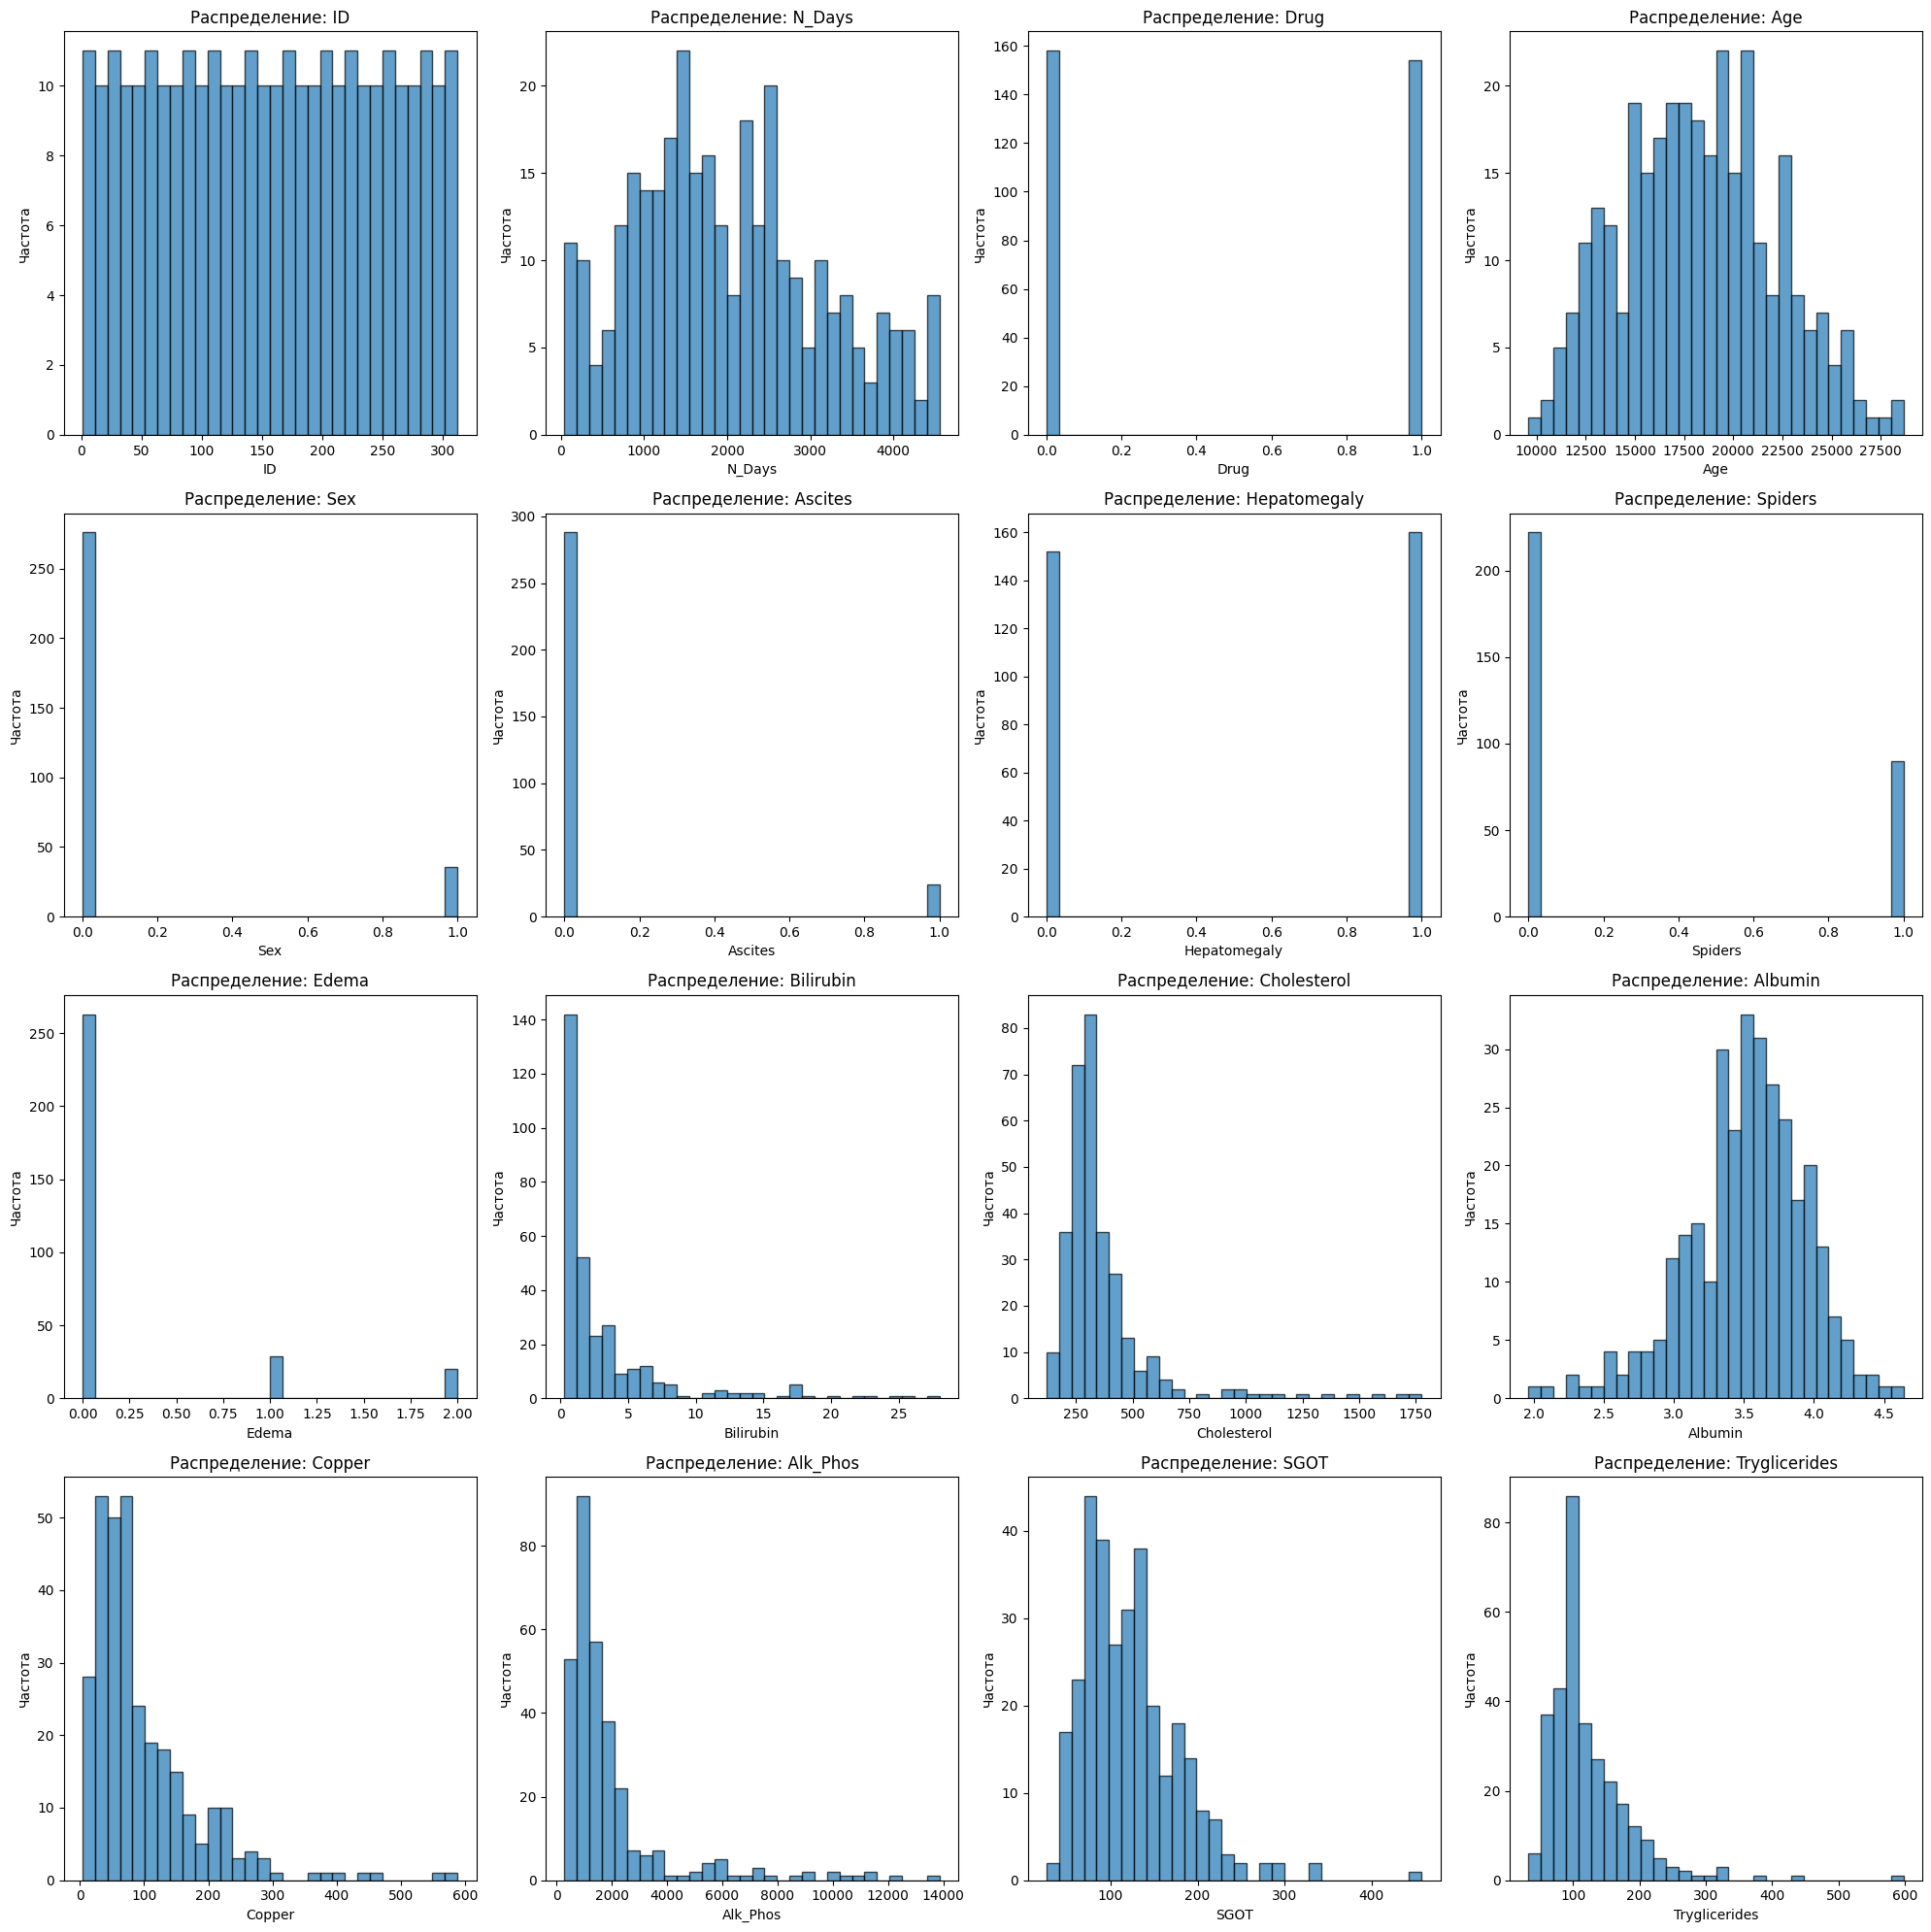

In [10]:
# Гистограммы числовых признаков
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('Status')  # Исключаем целевую переменную

fig, axes = plt.subplots(4, 4, figsize=(20, 20))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols[:16]):
    axes[idx].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Распределение: {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Частота')

plt.tight_layout()
plt.show()

# Предобработка данных

In [11]:
# Подготовка данных
X = df.drop(['ID', 'Stage'], axis=1)  # Исключаем ID и целевую переменную
y = df['Stage']

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [12]:
# Масштабирование признаков (важно для некоторых методов)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (249, 18)
Размер тестовой выборки: (63, 18)


# Функция для оценки моделей

In [13]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """Оценка модели регрессии"""
    # Обучение модели
    model.fit(X_train, y_train)

    # Предсказания
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Метрики
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    # Adjusted R²
    n = len(y_test)
    p = X_test.shape[1]
    adj_r2 = 1 - (1 - test_r2) * (n - 1) / (n - p - 1)

    # Cross-validated R²
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    cv_r2 = cv_scores.mean()

    print(f"\n{model_name}:")
    print(f"  Train RMSE: {train_rmse:.4f}")
    print(f"  Test RMSE:  {test_rmse:.4f}")
    print(f"  Train R²:   {train_r2:.4f}")
    print(f"  Test R²:    {test_r2:.4f}")
    print(f"  Adj. R²:    {adj_r2:.4f}")
    print(f"  CV R²:      {cv_r2:.4f}")

    return {
        'model': model,
        'name': model_name,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'adj_r2': adj_r2,
        'cv_r2': cv_r2
    }

In [14]:
results = []
# 1. Линейная регрессия
print("="*50)
lr = LinearRegression()
results.append(evaluate_model(lr, X_train_scaled, X_test_scaled, y_train, y_test, "Linear Regression"))


Linear Regression:
  Train RMSE: 0.7201
  Test RMSE:  0.6588
  Train R²:   0.3233
  Test R²:    0.4403
  Adj. R²:    0.2114
  CV R²:      0.1395


In [15]:
# 2. Ridge регрессия
print("="*50)
ridge = Ridge(alpha=1.0)
results.append(evaluate_model(ridge, X_train_scaled, X_test_scaled, y_train, y_test, "Ridge Regression"))


Ridge Regression:
  Train RMSE: 0.7201
  Test RMSE:  0.6587
  Train R²:   0.3233
  Test R²:    0.4406
  Adj. R²:    0.2118
  CV R²:      0.1413


In [16]:
# 3. Lasso регрессия
print("="*50)
lasso = Lasso(alpha=0.1, max_iter=10000)
results.append(evaluate_model(lasso, X_train_scaled, X_test_scaled, y_train, y_test, "Lasso Regression"))


Lasso Regression:
  Train RMSE: 0.7527
  Test RMSE:  0.7071
  Train R²:   0.2605
  Test R²:    0.3552
  Adj. R²:    0.0914
  CV R²:      0.1633


In [17]:
# 3. Lasso регрессия
print("="*50)
lasso = Lasso(alpha=0.1, max_iter=10000)
results.append(evaluate_model(lasso, X_train_scaled, X_test_scaled, y_train, y_test, "Lasso Regression"))


Lasso Regression:
  Train RMSE: 0.7527
  Test RMSE:  0.7071
  Train R²:   0.2605
  Test R²:    0.3552
  Adj. R²:    0.0914
  CV R²:      0.1633


In [18]:
#ElasticNet регрессия
print("="*50)
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)
results.append(evaluate_model(elastic, X_train_scaled, X_test_scaled, y_train, y_test, "ElasticNet Regression"))


ElasticNet Regression:
  Train RMSE: 0.7360
  Test RMSE:  0.6786
  Train R²:   0.2932
  Test R²:    0.4062
  Adj. R²:    0.1633
  CV R²:      0.1796


In [19]:
# 5. Bayesian Ridge регрессия
print("="*50)
bayesian = BayesianRidge()
results.append(evaluate_model(bayesian, X_train_scaled, X_test_scaled, y_train, y_test, "Bayesian Ridge Regression"))


Bayesian Ridge Regression:
  Train RMSE: 0.7268
  Test RMSE:  0.6664
  Train R²:   0.3106
  Test R²:    0.4273
  Adj. R²:    0.1931
  CV R²:      0.1875


In [20]:
# 6. Decision Tree регрессия
print("="*50)
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
results.append(evaluate_model(dt, X_train, X_test, y_train, y_test, "Decision Tree Regression"))


Decision Tree Regression:
  Train RMSE: 0.0811
  Test RMSE:  0.9149
  Train R²:   0.9914
  Test R²:    -0.0794
  Adj. R²:    -0.5209
  CV R²:      -0.5165


In [21]:
# 7. Random Forest регрессия
print("="*50)
rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42)
results.append(evaluate_model(rf, X_train, X_test, y_train, y_test, "Random Forest Regression"))



Random Forest Regression:
  Train RMSE: 0.2854
  Test RMSE:  0.6690
  Train R²:   0.8937
  Test R²:    0.4229
  Adj. R²:    0.1868
  CV R²:      0.1790


In [22]:
# 8. SVR (Support Vector Regression)
print("="*50)
svr = SVR(kernel='rbf', C=100, epsilon=0.1)
results.append(evaluate_model(svr, X_train_scaled, X_test_scaled, y_train, y_test, "SVR (RBF)"))


SVR (RBF):
  Train RMSE: 0.0973
  Test RMSE:  0.9547
  Train R²:   0.9877
  Test R²:    -0.1753
  Adj. R²:    -0.6560
  CV R²:      -0.4753


# Сравнение моделей


СРАВНЕНИЕ МОДЕЛЕЙ (отсортировано по Test R²):
                     name  test_rmse   test_r2    adj_r2     cv_r2
         Ridge Regression   0.658652  0.440598  0.211752  0.141285
        Linear Regression   0.658814  0.440322  0.211363  0.139524
Bayesian Ridge Regression   0.666406  0.427348  0.193081  0.187532
 Random Forest Regression   0.668983  0.422911  0.186830  0.178996
    ElasticNet Regression   0.678577  0.406241  0.163339  0.179572
         Lasso Regression   0.707140  0.355202  0.091421  0.163347
         Lasso Regression   0.707140  0.355202  0.091421  0.163347
 Decision Tree Regression   0.914916 -0.079382 -0.520948 -0.516492
                SVR (RBF)   0.954682 -0.175250 -0.656034 -0.475349


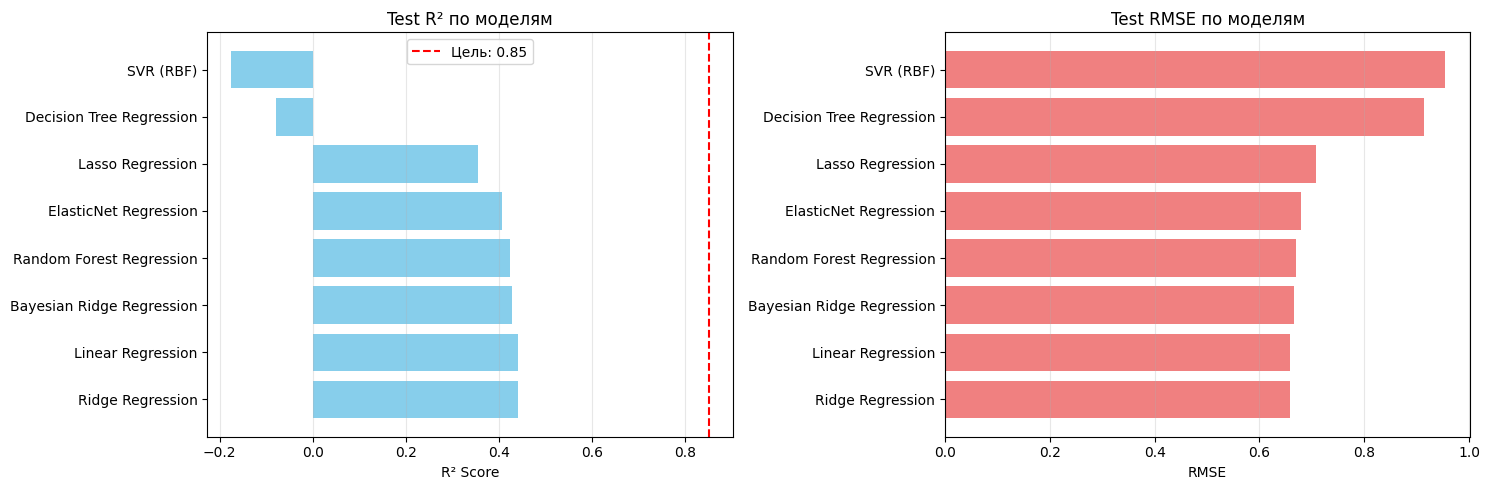

In [23]:
# Создание DataFrame с результатами
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('test_r2', ascending=False)

print("\n" + "="*80)
print("СРАВНЕНИЕ МОДЕЛЕЙ (отсортировано по Test R²):")
print("="*80)
print(results_df[['name', 'test_rmse', 'test_r2', 'adj_r2', 'cv_r2']].to_string(index=False))

# Визуализация сравнения
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Сравнение R²
axes[0].barh(results_df['name'], results_df['test_r2'], color='skyblue')
axes[0].set_xlabel('R² Score')
axes[0].set_title('Test R² по моделям')
axes[0].axvline(x=0.85, color='red', linestyle='--', label='Цель: 0.85')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

# Сравнение RMSE
axes[1].barh(results_df['name'], results_df['test_rmse'], color='lightcoral')
axes[1].set_xlabel('RMSE')
axes[1].set_title('Test RMSE по моделям')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

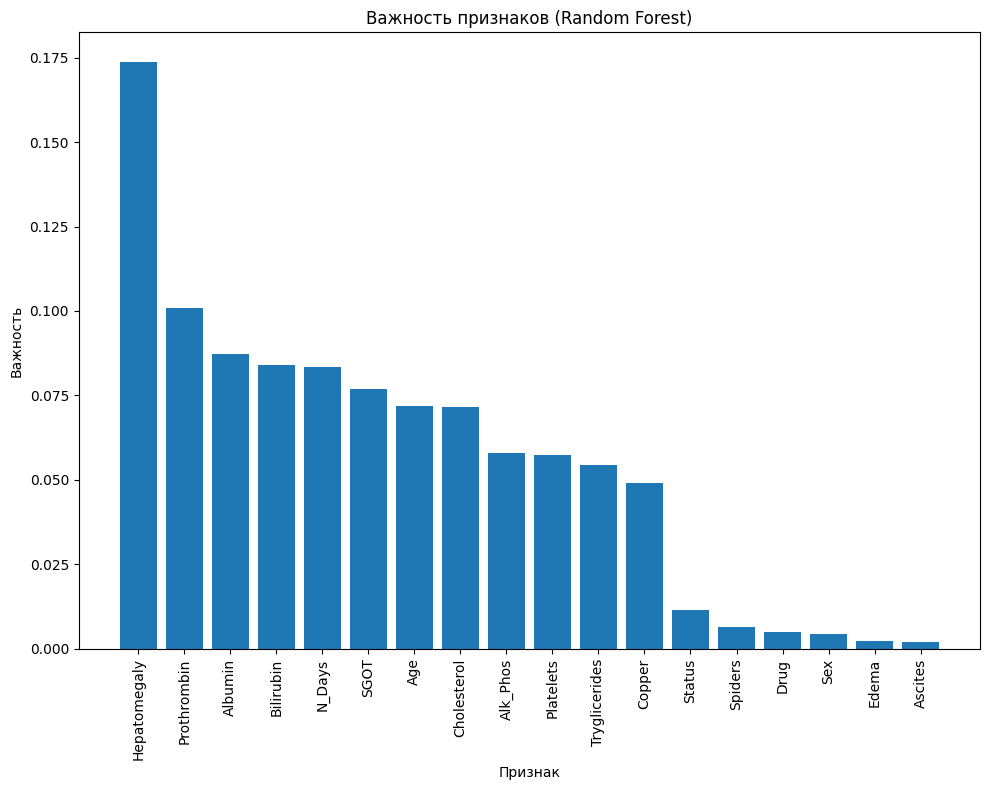


Топ-10 наиболее важных признаков:
1. Hepatomegaly: 0.1738
2. Prothrombin: 0.1010
3. Albumin: 0.0873
4. Bilirubin: 0.0842
5. N_Days: 0.0833
6. SGOT: 0.0768
7. Age: 0.0718
8. Cholesterol: 0.0715
9. Alk_Phos: 0.0578
10. Platelets: 0.0575


In [25]:
# Важность признаков для Random Forest (если он в топ-3)
if 'Random Forest Regression' in results_df['name'].values:
    rf_model = results_df[results_df['name'] == 'Random Forest Regression']['model'].values[0]

    plt.figure(figsize=(10, 8))
    importances = rf_model.feature_importances_
    indices = np.argsort(importances)[::-1]

    plt.bar(range(X.shape[1]), importances[indices])
    plt.xticks(range(X.shape[1]), [X.columns[i] for i in indices], rotation=90)
    plt.xlabel('Признак')
    plt.ylabel('Важность')
    plt.title('Важность признаков (Random Forest)')
    plt.tight_layout()
    plt.show()

    print("\nТоп-10 наиболее важных признаков:")
    for i in range(min(10, len(importances))):
        print(f"{i+1}. {X.columns[indices[i]]}: {importances[indices[i]]:.4f}")

#  Выбор лучшей модели и визуализация

In [29]:
# Выбор лучшей модели по CV R²
best_model = results_df.loc[results_df['cv_r2'].idxmax()]
print(f"\ Лучшая модель: {best_model['name']}")
print(f"   Test R²: {best_model['test_r2']:.4f}")
print(f"   Adj. R²: {best_model['adj_r2']:.4f}")
print(f"   CV R²: {best_model['cv_r2']:.4f}")



\ Лучшая модель: Bayesian Ridge Regression
   Test R²: 0.4273
   Adj. R²: 0.1931
   CV R²: 0.1875
